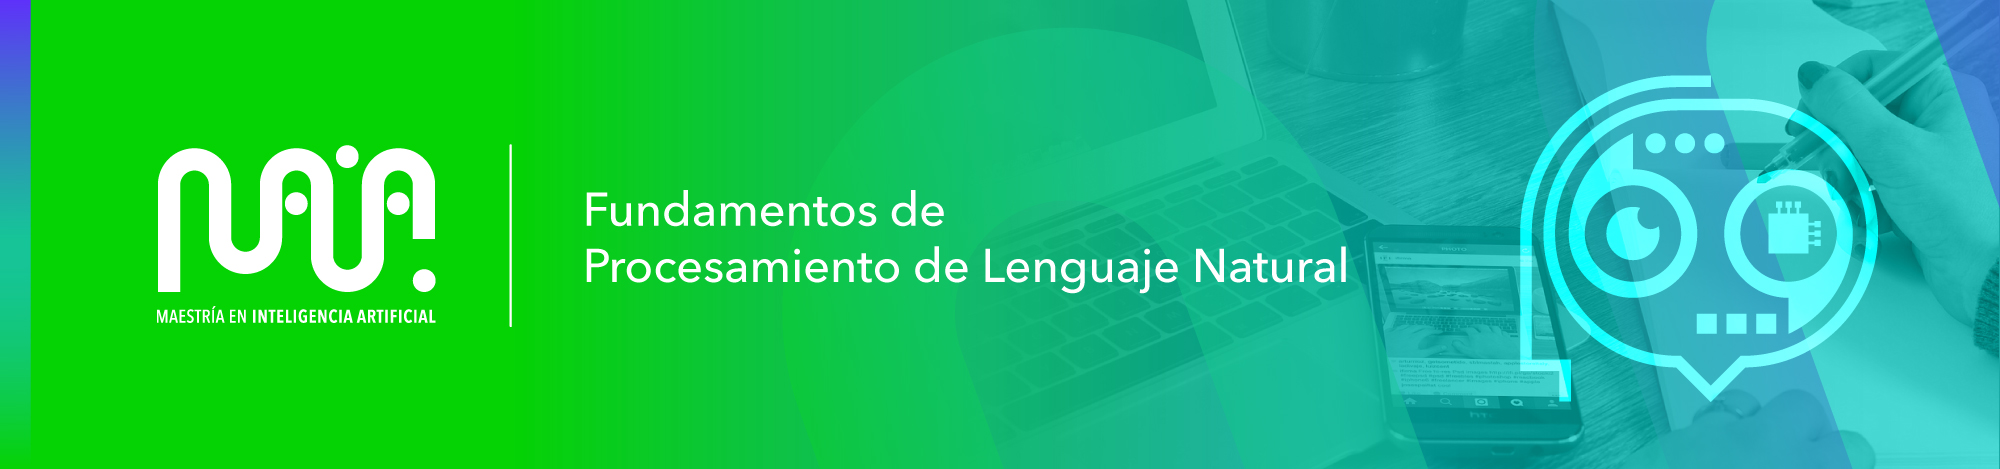
# Introducción

## Descripción
Mediante este notebook de Python se busca evaluar el conocimiento del estudiante para entrenar modelos de incrustaciones con **gensim** y usar modelos pre-entrenados que puedan
ser utilizados en tareas como la clasificación de texto.

Al final del desarrollo de este notebook se espera que el estudiante este en capacidad de:
1. Entrenar modelos de inscrustaciones utilizando **gensim**.
2. Utilizar modelos de incrustaciones pre-entrenados con **gensim**.
3. Utilizar las incrustaciones en tareas de clasificación de texto.
4. Evaluar el desempeño de distintas incrustaciones.

## Metodología
Este notebook consiste en la construcción de modelos de aprendizaje de máquina capaces de identificar correctamente una categoría de producto de acuerdo con reseñas de texto que fueron extraídas de Amazon a partir de las incrustaciones como representación de texto.

Estuctura del taller:
* [1. Exploración del dataset y procesamiento de texto](#1-exploración-del-dataset-y-procesamiento-del-texto)
* [2. Entrenamiento de modelos Word2Vec](#2-entrenamiento-de-modelos-word2vec)
    * [2.1. Ejercicio 1: Entrenar 3 modelos de incrustaciones](#21-ejercicio-1-entrenar-3-modelos-de-inscrustaciones)
* [3. Uso de modelos de incrustaciones pre-entrenados](#3-uso-de-modelos-de-incrustaciones-pre-entrenados)
    * [Ejercicio 2: Cargue un modelos de incrustaciones pre-entrenado](#31-ejercicio-2-cargue-un-modelo-de-incrustaciones-pre-entrenado)
* [4. Entrenamiento de clasificadores de texto](#4-entrenamiento-de-clasificadores-de-texto)
    * [4.1. Ejercicio 3: Implementar clase para generar las representaciones textuales](#41-ejercicio-3-implementar-clase-para-generar-las-representaciones-textuales)
    * [4.2. Ejercicio 4: Entrenar clasificadores de texto](#42-ejercicio-4-entrenar-clasificadores-de-texto)
* [5. Evaluación de la tarea de clasificación](#5-evaluación-de-la-tarea-de-clasificación)
* [6. Conclusiones](#6-conclusiones)

## Consideraciones
* Solo debe completar las funciones que se le indique de manera explícita.
* Este notebook se autocalificará mediante unos tests ocultos que probarán las funcionalidades implementadas.

Importación de los módulos a usar en el taller

In [3]:
import os
import re
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim
import gensim.downloader as api
from gensim.test.utils import datapath
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Descargue los clasificadores que quiera usar aquí
from sklearn.linear_model import LogisticRegression

In [4]:
# Configurar logging para ver el entrenamiento de Gensim
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

Constantes de nombres de los archivos a usar en el taller.

In [5]:
TRAIN_DATA = 'data/train_40k.csv'
EVAL_DATA = 'data/val_10k.csv'
EMBEDDINGS_100 = 'emb_100'
EMBEDDINGS_200 = 'emb_200'
EMBEDDINGS_300 = 'emb_300'

# 1. Exploración del dataset y procesamiento del texto

Para mayor comodidad en la manipulación de los datos cargaremos los archivos csv del dataset con DataFrames de Pandas.

In [6]:
# Cargar los datos de entrenamiento en un DataFrame
df_train = pd.read_csv(TRAIN_DATA)
df_eval = pd.read_csv(EVAL_DATA)

Luego eliminamos filas de los documentos sin títulos, y eliminamos las reseñas duplicadas.

In [7]:
def clean_data(train_data: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia los datos de entrenamiento. Elimina las filas con valores nulos , y los duplicados en la característica "Text".

    Args:
        train_data (pd.DataFrame): DataFrame con los datos de entrenamiento.

    Returns:
        pd.DataFrame: DataFrame con los datos limpios.
    """
    train_data = train_data.dropna(subset=['Title'])

    # Eliminar los duplicados
    train_data = train_data.drop_duplicates(subset=['Text'])

    return train_data

# Validando la implementación
df_eval = clean_data(df_eval)
df_train = clean_data(df_train)
df_train[["Title", "Text"]].describe()

,Title,Text
count,39473,39473
unique,19567,39473
top,Pampers Baby Dry Diapers (Packaging May Vary),The description and photo on this product need...
freq,268,1


Ahora generamos arreglos con el texto que usaremos como entrada de nuestos modelos clasificadores, y también generamos arreglos con las categorías correspondientes a cada reseña.

In [8]:
def pre_process_text(data: pd.DataFrame) -> tuple:
    """
    Preprocesa el texto para poder ser utilizado en un modelo de clasificación.

    Args:
        data (DataFrame): DataFrame con los datos a preprocesar.

    Returns:
        (tuple): Tupla con los datos preprocesados.
    """
    X = data['Title'] + '. ' + data['Text']
    y = data['Cat1']

    return X.values, y.values

X_eval, y_eval = pre_process_text(df_eval)
X_train, y_train = pre_process_text(df_train)
print(X_train.shape, y_train.shape)

(39473,) (39473,)


Definimos la función de tokenización que usaremos para entrenar los modelos Word2Vec.

In [9]:
def tokenize_text(text: str) -> "list[str]":
    """
    Procesa un texto y luego lo tokeniza.

    Args:
        text(str) texto a procesar y tokenizar.

    Returns:
        list[str] lista de tokens.
    """
    text = re.sub(r'[^a-z]', ' ', text.lower()) # Convertir a minúsculas y eliminar caracteres no alfabéticos
    text = re.sub(r'\s[a-z]([a-z])?\b', '', text) # Eliminar palabras de una o dos letras
    return text.split() # Tokenizar


sample = X_train[0]
print('Texto original:')
print(sample)
print('Texto procesado y tokenizado:')
print(tokenize_text(sample))

Texto original:
Golden Valley Natural Buffalo Jerky. The description and photo on this product needs to be changed to indicate this product is the BuffalOs version of this beef jerky.
Texto procesado y tokenizado:
['golden', 'valley', 'natural', 'buffalo', 'jerky', 'the', 'description', 'and', 'photo', 'this', 'product', 'needs', 'changed', 'indicate', 'this', 'product', 'the', 'buffalos', 'version', 'this', 'beef', 'jerky']


Finalmente, creamos una clase para iterar, procesar y tokenizar el corpus de entrenamiento:

In [10]:
class MyCorpus:
    def __init__(self, documents):
        self.documents = documents

    def __iter__(self):
        for document in self.documents:
            yield tokenize_text(document)

    def __len__(self):
        return len(self.documents)
    
    def __getitem__(self, index):
        return tokenize_text(self.documents[index])

corpus = MyCorpus(X_train)
len(corpus)

39473

# 2. Entrenamiento de modelos Word2Vec

## 2.1. Ejercicio 1: Entrenar 3 modelos de inscrustaciones

En este ejercicio usted debe hacer uso de la clase `Word2Vec` de **gensim** para entrenar modelos de incrustaciones haciendo uso del corpus de entrenamiento. Debe entrenar 3 modelos con representaciones de tamaño 100, 200 y 300 que se hayan entrenado con por lo menos 10 épocas. Los demás parámetros puede definirlos a su gusto.

Una vez entrenados los modelos debe guardarlos en el path definido por las constantes `EMBEDDINGS_100`, `EMBEDDINGS_200`, y `EMBEDDINGS_300`.

In [11]:
# Use esta celda para entrenar el modelo de Word2Vec con un tamaño de incrustación de 100

## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
model1 = gensim.models.Word2Vec(
    corpus, 
    vector_size=100, 
    window=2, 
    min_count=5,     
    workers=1, 
    negative=5,      
    sg=0,            
    epochs=10, 
    seed=37
)
model1.save(EMBEDDINGS_100)
#raise NotImplementedError

2026-03-04 14:49:53,905 : INFO : collecting all words and their counts
2026-03-04 14:49:53,906 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-04 14:49:54,524 : INFO : PROGRESS: at sentence #10000, processed 752563 words, keeping 26535 word types
2026-03-04 14:49:55,077 : INFO : PROGRESS: at sentence #20000, processed 1414675 words, keeping 36454 word types
2026-03-04 14:49:55,653 : INFO : PROGRESS: at sentence #30000, processed 2098896 words, keeping 43838 word types
2026-03-04 14:49:56,194 : INFO : collected 49982 word types from a corpus of 2741659 raw words and 39473 sentences
2026-03-04 14:49:56,194 : INFO : Creating a fresh vocabulary
2026-03-04 14:49:56,248 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 16783 unique words (33.58% of original 49982, drops 33199)', 'datetime': '2026-03-04T14:49:56.248868', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platf

2026-03-04 14:50:38,546 : INFO : EPOCH 7 - PROGRESS: at 95.93% examples, 420895 words/s, in_qsize 1, out_qsize 0
2026-03-04 14:50:38,740 : INFO : EPOCH 7: training on 2741659 raw words (2212914 effective words) took 5.2s, 422002 effective words/s
2026-03-04 14:50:39,754 : INFO : EPOCH 8 - PROGRESS: at 16.50% examples, 409124 words/s, in_qsize 1, out_qsize 0
2026-03-04 14:50:40,766 : INFO : EPOCH 8 - PROGRESS: at 36.41% examples, 414561 words/s, in_qsize 1, out_qsize 0
2026-03-04 14:50:41,771 : INFO : EPOCH 8 - PROGRESS: at 56.19% examples, 415208 words/s, in_qsize 1, out_qsize 0
2026-03-04 14:50:42,773 : INFO : EPOCH 8 - PROGRESS: at 75.23% examples, 415905 words/s, in_qsize 1, out_qsize 0
2026-03-04 14:50:43,782 : INFO : EPOCH 8 - PROGRESS: at 94.57% examples, 415669 words/s, in_qsize 1, out_qsize 0
2026-03-04 14:50:44,051 : INFO : EPOCH 8: training on 2741659 raw words (2212514 effective words) took 5.3s, 417036 effective words/s
2026-03-04 14:50:45,070 : INFO : EPOCH 9 - PROGRESS: a

In [12]:
%%time
# Use esta celda para entrenar el modelo de Word2Vec con un tamaño de incrustación de 200

## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
model2 = gensim.models.Word2Vec(
    corpus, 
    vector_size=200, 
    window=5,        
    min_count=2, 
    workers=4,       
    negative=10, 
    sg=1,            
    epochs=10, 
    seed=37
)
model2.save(EMBEDDINGS_200)
#raise NotImplementedError

2026-03-04 14:54:24,005 : INFO : collecting all words and their counts
2026-03-04 14:54:24,005 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-04 14:54:24,633 : INFO : PROGRESS: at sentence #10000, processed 752563 words, keeping 26535 word types
2026-03-04 14:54:25,201 : INFO : PROGRESS: at sentence #20000, processed 1414675 words, keeping 36454 word types
2026-03-04 14:54:25,789 : INFO : PROGRESS: at sentence #30000, processed 2098896 words, keeping 43838 word types
2026-03-04 14:54:26,337 : INFO : collected 49982 word types from a corpus of 2741659 raw words and 39473 sentences
2026-03-04 14:54:26,338 : INFO : Creating a fresh vocabulary
2026-03-04 14:54:26,424 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 28438 unique words (56.90% of original 49982, drops 21544)', 'datetime': '2026-03-04T14:54:26.424165', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platf

2026-03-04 14:55:14,510 : INFO : EPOCH 3 - PROGRESS: at 11.38% examples, 142099 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:15,525 : INFO : EPOCH 3 - PROGRESS: at 17.12% examples, 142446 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:16,534 : INFO : EPOCH 3 - PROGRESS: at 23.90% examples, 143048 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:17,580 : INFO : EPOCH 3 - PROGRESS: at 31.08% examples, 144138 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:18,684 : INFO : EPOCH 3 - PROGRESS: at 37.97% examples, 142196 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:19,743 : INFO : EPOCH 3 - PROGRESS: at 44.43% examples, 140599 words/s, in_qsize 8, out_qsize 0
2026-03-04 14:55:20,828 : INFO : EPOCH 3 - PROGRESS: at 51.27% examples, 139967 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:21,848 : INFO : EPOCH 3 - PROGRESS: at 57.93% examples, 140416 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:55:22,889 : INFO : EPOCH 3 - PROGRESS: at 64.48% examples, 140506 words/s, in_qsiz

2026-03-04 14:56:26,229 : INFO : EPOCH 7 - PROGRESS: at 82.69% examples, 136765 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:56:27,287 : INFO : EPOCH 7 - PROGRESS: at 91.39% examples, 139709 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:56:28,293 : INFO : EPOCH 7 - PROGRESS: at 98.19% examples, 140685 words/s, in_qsize 5, out_qsize 0
2026-03-04 14:56:28,529 : INFO : EPOCH 7: training on 2741659 raw words (2246713 effective words) took 15.9s, 141070 effective words/s
2026-03-04 14:56:29,609 : INFO : EPOCH 8 - PROGRESS: at 6.90% examples, 157860 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:56:30,628 : INFO : EPOCH 8 - PROGRESS: at 12.76% examples, 153874 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:56:31,647 : INFO : EPOCH 8 - PROGRESS: at 18.80% examples, 152973 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:56:32,660 : INFO : EPOCH 8 - PROGRESS: at 26.16% examples, 152858 words/s, in_qsize 7, out_qsize 0
2026-03-04 14:56:33,682 : INFO : EPOCH 8 - PROGRESS: at 33.38% examples, 15

CPU times: user 9min 54s, sys: 360 ms, total: 9min 54s
Wall time: 2min 31s


In [13]:
%%time
# Use esta celda para entrenar el modelo de Word2Vec con un tamaño de incrustación de 300

## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
model3 = gensim.models.Word2Vec(
    corpus, 
    vector_size=300, 
    window=10,       
    min_count=2, 
    workers=4, 
    negative=20,     
    sg=1,            
    epochs=10, 
    seed=37
)
model3.save(EMBEDDINGS_300)
#raise NotImplementedError

2026-03-04 14:59:20,979 : INFO : collecting all words and their counts
2026-03-04 14:59:20,980 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-04 14:59:21,606 : INFO : PROGRESS: at sentence #10000, processed 752563 words, keeping 26535 word types
2026-03-04 14:59:22,144 : INFO : PROGRESS: at sentence #20000, processed 1414675 words, keeping 36454 word types
2026-03-04 14:59:22,724 : INFO : PROGRESS: at sentence #30000, processed 2098896 words, keeping 43838 word types
2026-03-04 14:59:23,251 : INFO : collected 49982 word types from a corpus of 2741659 raw words and 39473 sentences
2026-03-04 14:59:23,252 : INFO : Creating a fresh vocabulary
2026-03-04 14:59:23,339 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 28438 unique words (56.90% of original 49982, drops 21544)', 'datetime': '2026-03-04T14:59:23.339755', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platf

2026-03-04 15:00:19,477 : INFO : EPOCH 0 - PROGRESS: at 93.90% examples, 37874 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:00:20,492 : INFO : EPOCH 0 - PROGRESS: at 95.57% examples, 37921 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:00:21,885 : INFO : EPOCH 0 - PROGRESS: at 97.39% examples, 37718 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:00:23,094 : INFO : EPOCH 0 - PROGRESS: at 99.26% examples, 37613 words/s, in_qsize 2, out_qsize 1
2026-03-04 15:00:23,116 : INFO : EPOCH 0: training on 2741659 raw words (2247496 effective words) took 59.3s, 37875 effective words/s
2026-03-04 15:00:24,130 : INFO : EPOCH 1 - PROGRESS: at 1.48% examples, 32161 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:00:25,163 : INFO : EPOCH 1 - PROGRESS: at 2.83% examples, 31616 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:00:26,387 : INFO : EPOCH 1 - PROGRESS: at 4.40% examples, 32103 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:00:27,484 : INFO : EPOCH 1 - PROGRESS: at 5.93% examples, 33288 words/s

2026-03-04 15:01:45,995 : INFO : EPOCH 2 - PROGRESS: at 39.17% examples, 37994 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:47,067 : INFO : EPOCH 2 - PROGRESS: at 40.91% examples, 37998 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:48,664 : INFO : EPOCH 2 - PROGRESS: at 43.64% examples, 37864 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:49,818 : INFO : EPOCH 2 - PROGRESS: at 46.39% examples, 38364 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:51,080 : INFO : EPOCH 2 - PROGRESS: at 48.31% examples, 38109 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:52,267 : INFO : EPOCH 2 - PROGRESS: at 50.54% examples, 38230 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:53,316 : INFO : EPOCH 2 - PROGRESS: at 52.36% examples, 38249 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:54,608 : INFO : EPOCH 2 - PROGRESS: at 55.05% examples, 38486 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:01:55,674 : INFO : EPOCH 2 - PROGRESS: at 57.28% examples, 38726 words/s, in_qsize 7, out_

2026-03-04 15:03:12,220 : INFO : EPOCH 3 - PROGRESS: at 88.38% examples, 37347 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:03:13,383 : INFO : EPOCH 3 - PROGRESS: at 90.29% examples, 37302 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:03:14,507 : INFO : EPOCH 3 - PROGRESS: at 92.50% examples, 37431 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:03:15,738 : INFO : EPOCH 3 - PROGRESS: at 94.23% examples, 37341 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:03:16,829 : INFO : EPOCH 3 - PROGRESS: at 96.31% examples, 37488 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:03:18,052 : INFO : EPOCH 3 - PROGRESS: at 98.57% examples, 37545 words/s, in_qsize 4, out_qsize 0
2026-03-04 15:03:18,704 : INFO : EPOCH 3: training on 2741659 raw words (2247424 effective words) took 59.7s, 37654 effective words/s
2026-03-04 15:03:20,165 : INFO : EPOCH 4 - PROGRESS: at 1.80% examples, 27813 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:03:21,352 : INFO : EPOCH 4 - PROGRESS: at 4.07% examples, 36646 words

2026-03-04 15:04:39,196 : INFO : EPOCH 5 - PROGRESS: at 36.03% examples, 39240 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:40,756 : INFO : EPOCH 5 - PROGRESS: at 39.17% examples, 39433 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:41,995 : INFO : EPOCH 5 - PROGRESS: at 41.61% examples, 39769 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:43,104 : INFO : EPOCH 5 - PROGRESS: at 43.64% examples, 39641 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:44,192 : INFO : EPOCH 5 - PROGRESS: at 45.55% examples, 39561 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:45,630 : INFO : EPOCH 5 - PROGRESS: at 47.91% examples, 39291 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:46,877 : INFO : EPOCH 5 - PROGRESS: at 49.78% examples, 39011 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:47,939 : INFO : EPOCH 5 - PROGRESS: at 51.65% examples, 38986 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:04:49,137 : INFO : EPOCH 5 - PROGRESS: at 53.82% examples, 39054 words/s, in_qsize 7, out_

2026-03-04 15:06:09,384 : INFO : EPOCH 6 - PROGRESS: at 92.87% examples, 38501 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:06:10,438 : INFO : EPOCH 6 - PROGRESS: at 94.57% examples, 38508 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:06:11,633 : INFO : EPOCH 6 - PROGRESS: at 96.31% examples, 38421 words/s, in_qsize 8, out_qsize 0
2026-03-04 15:06:12,655 : INFO : EPOCH 6 - PROGRESS: at 97.79% examples, 38308 words/s, in_qsize 6, out_qsize 0
2026-03-04 15:06:13,665 : INFO : EPOCH 6 - PROGRESS: at 100.00% examples, 38459 words/s, in_qsize 0, out_qsize 1
2026-03-04 15:06:13,666 : INFO : EPOCH 6: training on 2741659 raw words (2247626 effective words) took 58.4s, 38458 effective words/s
2026-03-04 15:06:14,792 : INFO : EPOCH 7 - PROGRESS: at 1.48% examples, 28897 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:06:15,863 : INFO : EPOCH 7 - PROGRESS: at 2.83% examples, 29506 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:06:16,937 : INFO : EPOCH 7 - PROGRESS: at 4.07% examples, 29661 words

2026-03-04 15:07:28,208 : INFO : EPOCH 8 - PROGRESS: at 20.38% examples, 35053 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:29,265 : INFO : EPOCH 8 - PROGRESS: at 22.32% examples, 35290 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:30,754 : INFO : EPOCH 8 - PROGRESS: at 24.68% examples, 35057 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:31,773 : INFO : EPOCH 8 - PROGRESS: at 26.16% examples, 34889 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:32,790 : INFO : EPOCH 8 - PROGRESS: at 27.68% examples, 34741 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:33,826 : INFO : EPOCH 8 - PROGRESS: at 29.23% examples, 34579 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:34,854 : INFO : EPOCH 8 - PROGRESS: at 30.66% examples, 34435 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:35,871 : INFO : EPOCH 8 - PROGRESS: at 32.23% examples, 34330 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:07:36,887 : INFO : EPOCH 8 - PROGRESS: at 33.78% examples, 34227 words/s, in_qsize 7, out_

2026-03-04 15:08:51,286 : INFO : EPOCH 9 - PROGRESS: at 57.97% examples, 38605 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:52,331 : INFO : EPOCH 9 - PROGRESS: at 59.67% examples, 38611 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:53,406 : INFO : EPOCH 9 - PROGRESS: at 61.43% examples, 38594 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:54,452 : INFO : EPOCH 9 - PROGRESS: at 63.01% examples, 38389 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:55,506 : INFO : EPOCH 9 - PROGRESS: at 64.52% examples, 38190 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:56,898 : INFO : EPOCH 9 - PROGRESS: at 66.24% examples, 37877 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:58,198 : INFO : EPOCH 9 - PROGRESS: at 68.50% examples, 37869 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:08:59,437 : INFO : EPOCH 9 - PROGRESS: at 70.34% examples, 37728 words/s, in_qsize 7, out_qsize 0
2026-03-04 15:09:00,459 : INFO : EPOCH 9 - PROGRESS: at 72.58% examples, 37975 words/s, in_qsize 7, out_

CPU times: user 39min 28s, sys: 659 ms, total: 39min 28s
Wall time: 9min 55s


# 3. Uso de modelos de incrustaciones pre-entrenados

## 3.1. Ejercicio 2: Cargue un modelo de incrustaciones pre-entrenado

**Gensim** dispone de modelos de incrustaciones pre-entrenados en distintos corpus que facilitan el reuso de las representaciones textuales generadas para distintas tareas de PLN. 

Para este taller el modelo fue descargado y guardado en el entorno de ejecución, y puede cargarlo así:  `gensim.models.KeyedVectors.load('glove-wiki-gigaword-300')`.

In [15]:
# Use esta celda para cargar el modelo

## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
glove_model = gensim.models.KeyedVectors.load('glove-wiki-gigaword-300')
#raise NotImplementedError

2026-03-04 15:25:26,517 : INFO : loading KeyedVectors object from glove-wiki-gigaword-300
2026-03-04 15:25:26,554 : INFO : KeyedVectors lifecycle event {'fname': 'glove-wiki-gigaword-300', 'datetime': '2026-03-04T15:25:26.554958', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}


Ahora use el modelo pre-entrenado para evaluar su desempeño en el dataset `wordsim353.tsv` disponible en **gensim**.

**Importante**: Debe guardar los resultados de evaluación obtenidos en una variable con el nombre de `results_glove`.

In [17]:
# Realice la evaluación de modelo de incrustaciones de GloVe

## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
results_glove = glove_model.evaluate_word_pairs(datapath('wordsim353.tsv'))
print(f"Pearson correlation: {results_glove[0][0]:.2f}")
print(f"Spearman correlation: {results_glove[1][0]:.2f}")
#raise NotImplementedError

2026-03-04 15:33:10,682 : INFO : Skipping line #24 with OOV words: stock	CD	1.31
2026-03-04 15:33:10,683 : INFO : Skipping line #38 with OOV words: bishop	rabbi	6.69
2026-03-04 15:33:10,683 : INFO : Skipping line #39 with OOV words: Jerusalem	Israel	8.46
2026-03-04 15:33:10,683 : INFO : Skipping line #40 with OOV words: Jerusalem	Palestinian	7.65
2026-03-04 15:33:10,684 : INFO : Skipping line #42 with OOV words: fuck	sex	9.44
2026-03-04 15:33:10,684 : INFO : Skipping line #43 with OOV words: Maradona	football	8.62
2026-03-04 15:33:10,685 : INFO : Skipping line #48 with OOV words: Arafat	peace	6.73
2026-03-04 15:33:10,686 : INFO : Skipping line #49 with OOV words: Arafat	terror	7.65
2026-03-04 15:33:10,686 : INFO : Skipping line #50 with OOV words: Arafat	Jackson	2.50
2026-03-04 15:33:10,686 : INFO : Skipping line #51 with OOV words: law	lawyer	8.38
2026-03-04 15:33:10,687 : INFO : Skipping line #75 with OOV words: midday	noon	9.29
2026-03-04 15:33:10,688 : INFO : Skipping line #80 with

2026-03-04 15:33:10,733 : INFO : Pairs with unknown words ratio: 25.2%


Pearson correlation: 0.60
Spearman correlation: 0.58


# 4. Entrenamiento de clasificadores de texto

En esta sección se utilizará el promedio de las inscrustaciones como representación de cada reseña y se entrenarán distintos modelos de clasificación para predecir la categoría de producto de la reseña.

## 4.1. Ejercicio 3: Implementar clase para generar las representaciones textuales

En este ejercicio debe implementar la clase `Text_Preprocessing`, la cual debe ser compatible con los Pipeline de **sklearn** y debe recibir el nombre de un modelo de incrustaciones a cargar para tokenizar el texto y crear un vector equivalente al promedio de cada uno de los tokens presentes en la reseña.

In [19]:
class Text_Preprocessing:
    def __init__(self, model_path: str):
        """
        Esta clase se encarga de cargar un modelo de incrustaciones de palabras, tokenizar un texto, y crear un vector equivalente al promedio de cada una de las incrustaciones
        de los tokens de la reseña.

        Args:
            model_path (str): Ruta al modelo de incrustaciones de palabras.
        """
        self.model_path = model_path

    def _tokenize_text(self, text: str) -> "list[str]":
        return tokenize_text(text)
    
    def transform(self, X: "list[str]") -> "np.array":
        """
        Crea un vector en representación de cada reseña como el promedio de las incrustaciones de las palabras en la reseña.
        1. Carga el modelo de incrustaciones de palabras (debe poder cargar el modelo ya sea un modelo de incrustaciones guardado localmente
            o el modelo de incrustaciones pre-entrenado previamente descargado).
        2. Guarda el modelo de incrustaciones de palabras en un atributo de la clase para que pueda usarlo en el método _embed.
        3. Utilice el método _embed para obtener el vector de incrustación de cada reseña.
        4. Retorne un arreglo de numpy con los vectores de incrustación de cada reseña.

        Args:
            X (list[str]): Lista de reseñas.

        Returns:
            np.array: Arreglo de numpy con los vectores de incrustación de cada reseña.
        """
        # Complete el cuerpo del método
        ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
        # your code here
        self.model = gensim.models.KeyedVectors.load(self.model_path)
        embeddings = [self._embed(review) for review in X]
        return np.array(embeddings) 
        #raise NotImplementedError
        ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS DE ESTA LÍNEA)

    def _embed(self, x: str) -> "np.array":
        """
        Crea un vector en representación de cada reseña como el promedio de las incrustaciones de las palabras en la reseña.
        1. Tokeniza el texto.
        2. Obtiene las incrustaciones de cada uno de los tokens.
        3. Calcula el promedio de las incrustaciones de los tokens.

        Args:
            x (str): Texto a incrustar.

        Returns:
            np.array: Vector de incrustación de la reseña.
        """
        # Complete el cuerpo del método
        ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
        # your code here
        tokens = self._tokenize_text(x)
        if hasattr(self.model, 'wv'):
            vectors = [self.model.wv[word] for word in tokens if word in self.model.wv]
            v_size = self.model.vector_size
        else:
            vectors = [self.model[word] for word in tokens if word in self.model]
            v_size = self.model.vector_size
        if not vectors:
            return np.zeros(self.model.vector_size)
        return np.mean(vectors, axis=0)
    
        #raise NotImplementedError
        ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS DE ESTA LÍNEA)

    def fit(self, X, y=None):
        return self
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def __repr__(self) -> str:
        return self.model_path
    
# Pruebe su implementación
preprocessor = Text_Preprocessing(EMBEDDINGS_100)
sample_text = [
    "This is a test",
    "This is another test"
]
sample_vectors = preprocessor.transform(sample_text)
print(sample_vectors.shape)
# Si su implementación es correcta debe imprimir (2, 100)

2026-03-04 16:54:39,269 : INFO : loading KeyedVectors object from emb_100
2026-03-04 16:54:39,295 : INFO : loading wv recursively from emb_100.wv.* with mmap=None
2026-03-04 16:54:39,295 : INFO : setting ignored attribute cum_table to None
2026-03-04 16:54:39,447 : INFO : Word2Vec lifecycle event {'fname': 'emb_100', 'datetime': '2026-03-04T16:54:39.447794', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}


(2, 100)


## 4.2. Ejercicio 4: Entrenar clasificadores de texto

En esta sección debe usar `GridSearchCV` para entrenar **por lo menos DOS modelos**, de los cuales uno debe ser un modelo que use las incrustaciones pre-entrenadas, y el otro debe hacer uso de alguna de las incrustaciones entrenadas.

La instancia de `GridSearch` debe guardarla en una variable con el nombre de `search`.

**Nota**: Se recomienda utilizar solo 2 rondas de validación cruzada y evaluar un solo clasificador (por ejemplo regresión logística) para reducir los tiempos de entrenamiento.

In [22]:
# Entrene la instancia de GridSearchCV con X_train y y_train
## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
pipeline = Pipeline([
    ('preprocessing', Text_Preprocessing(model_path='')), 
    ('clf', LogisticRegression(max_iter=1000))
])

# 2. Definimos la malla de parámetros (param_grid)
# Queremos probar al menos dos modelos de incrustaciones distintos
param_grid = {
    'preprocessing__model_path': [
        'glove-wiki-gigaword-300',  
        EMBEDDINGS_300                    
    ],
    'clf__C': [1.0] 
}

search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=2, 
    scoring='accuracy',
    verbose=3
)

search.fit(X_train, y_train)

2026-03-04 17:10:46,170 : INFO : loading KeyedVectors object from glove-wiki-gigaword-300
2026-03-04 17:10:46,218 : INFO : KeyedVectors lifecycle event {'fname': 'glove-wiki-gigaword-300', 'datetime': '2026-03-04T17:10:46.218506', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}


Fitting 2 folds for each of 2 candidates, totalling 4 fits


2026-03-04 17:11:29,529 : INFO : loading KeyedVectors object from glove-wiki-gigaword-300
2026-03-04 17:11:29,632 : INFO : KeyedVectors lifecycle event {'fname': 'glove-wiki-gigaword-300', 'datetime': '2026-03-04T17:11:29.632411', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}
2026-03-04 17:11:34,643 : INFO : loading KeyedVectors object from glove-wiki-gigaword-300
2026-03-04 17:11:34,672 : INFO : KeyedVectors lifecycle event {'fname': 'glove-wiki-gigaword-300', 'datetime': '2026-03-04T17:11:34.672194', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}


[CV 1/2] END clf__C=1.0, preprocessing__model_path=glove-wiki-gigaword-300;, score=0.851 total time=  48.5s


2026-03-04 17:12:15,727 : INFO : loading KeyedVectors object from glove-wiki-gigaword-300
2026-03-04 17:12:15,834 : INFO : KeyedVectors lifecycle event {'fname': 'glove-wiki-gigaword-300', 'datetime': '2026-03-04T17:12:15.834404', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}
2026-03-04 17:12:20,730 : INFO : loading KeyedVectors object from emb_300


...

[CV 1/2] END clf__C=1.0, preprocessing__model_path=emb_300;, score=0.904 total time=  33.0s


2026-03-04 17:12:54,065 : INFO : Word2Vec lifecycle event {'fname': 'emb_300', 'datetime': '2026-03-04T17:12:54.065645', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}
2026-03-04 17:13:23,341 : INFO : loading KeyedVectors object from emb_300
2026-03-04 17:13:23,544 : INFO : loading wv recursively from emb_300.wv.* with mmap=None
2026-03-04 17:13:23,545 : INFO : setting ignored attribute cum_table to None
2026-03-04 17:13:23,807 : INFO : Word2Vec lifecycle event {'fname': 'emb_300', 'datetime': '2026-03-04T17:13:23.807186', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}
2026-03-04 17:13:28,830 : INFO : loading KeyedVectors object from emb_300
2026-03-04 17:13:28,883 : INFO : loading wv recursively from emb_300.w

[CV 2/2] END clf__C=1.0, preprocessing__model_path=emb_300;, score=0.891 total time=  35.0s


2026-03-04 17:13:29,149 : INFO : Word2Vec lifecycle event {'fname': 'emb_300', 'datetime': '2026-03-04T17:13:29.149129', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessing', ),
                                       ('clf',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'clf__C': [1.0],
                         'preprocessing__model_path': ['glove-wiki-gigaword-300',
                                                       'emb_300']},
             scoring='accuracy', verbose=3)

Revise los resultados obtenidos con la búsqueda de grilla y guarde los resultados en un archivo `csv`.

In [23]:
df_results = pd.DataFrame(search.cv_results_)
df_results.to_csv('results.csv')
df_results.sort_values(by='mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_preprocessing__model_path,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
1,28.507163,1.093404,5.494439,0.089237,1.0,emb_300,"{'clf__C': 1.0, 'preprocessing__model_path': '...",0.904393,0.891011,0.897702,0.006691,1
0,42.225560,1.140263,5.050535,0.056386,1.0,glove-wiki-gigaword-300,"{'clf__C': 1.0, 'preprocessing__model_path': '...",0.850889,0.819974,0.835431,0.015458,2


# 5. Evaluación de la tarea de clasificación

En esta sección se hace la evluación del mejor modelo encontrado en la búsqueda de grilla en la tarea de clasifiación de la categoría de producto según la reseña.

2026-03-04 17:17:11,367 : INFO : loading KeyedVectors object from emb_300
2026-03-04 17:17:11,425 : INFO : loading wv recursively from emb_300.wv.* with mmap=None
2026-03-04 17:17:11,425 : INFO : setting ignored attribute cum_table to None
2026-03-04 17:17:11,695 : INFO : Word2Vec lifecycle event {'fname': 'emb_300', 'datetime': '2026-03-04T17:17:11.695532', 'gensim': '4.3.2', 'python': '3.10.6 | packaged by conda-forge | (main, Aug 22 2022, 20:35:26) [GCC 10.4.0]', 'platform': 'Linux-6.5.0-1024-aws-x86_64-with-glibc2.35', 'event': 'loaded'}


                      precision    recall  f1-score   support

       baby products       0.84      0.83      0.84       696
              beauty       0.90      0.88      0.89      2069
grocery gourmet food       0.88      0.84      0.86       832
health personal care       0.85      0.88      0.86      2935
        pet supplies       0.95      0.89      0.92      1564
          toys games       0.90      0.94      0.92      1753

            accuracy                           0.89      9849
           macro avg       0.89      0.88      0.88      9849
        weighted avg       0.89      0.89      0.89      9849



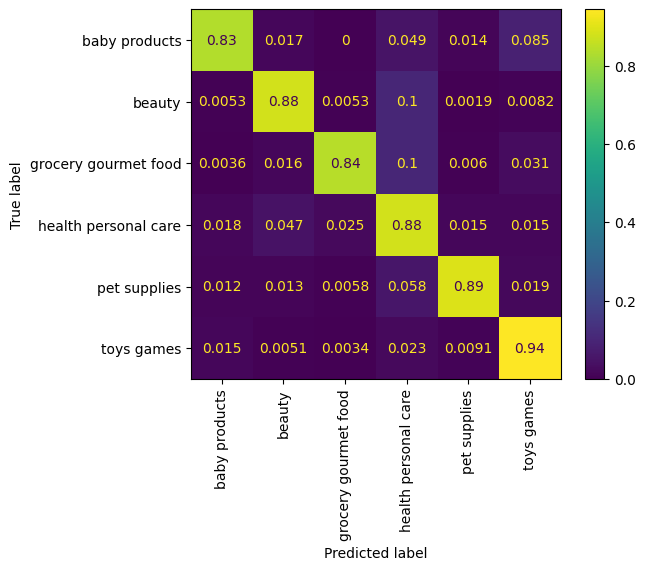

In [24]:
# Genere las predicciones de la reseñas de evaluación
y_pred = search.predict(X_eval)

# Imprimir el reporte de clasificación
print(classification_report(y_eval, y_pred, target_names=search.classes_))

# Graficar la matriz de confusión
conf_mtx = confusion_matrix(y_eval, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(conf_mtx, display_labels=search.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# 6. Conclusiones

Las incrustaciones son representaciones textuales densas que pueden tener beneficios frente a las representaciones dispersas (como las bolsas de palabras) principalmente en memoria y en la preservación de información semántica. Sin embargo, su utilidad debe evaluarse directamente en la tarea que se pretenda resolver.

Adicionalmente, se debe tener en cuenta que para este taller se usó como representación de la reseña el promedio de las incrustaciones de los tokens que la componen. Al realizar este proceso se destruyó la información secuencial del texto de igual manera que sucede con las representaciones de bolsa de palabra. Pero, debe tenerse en cuenta que existen modelos capaces de procesar información secuencial que podrían sacar mejor provecho de la información conservada por estas incrustaciones.